# Behavioral Analysis for Wolbachia Experiment

## Imports and functions

In [1]:
import pickle
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import re
import pingouin
from scipy import stats
import seaborn as sns

import unityvr.preproc.logproc as lp
from unityvr.analysis import posAnalysis

from gulp2p.preproc import utils
from gulp2p.viz import plotting 


c:\Users\ahshenas\Anaconda3\envs\gulp2p\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.4.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


## Select data files

### Batch pickle creation

In [2]:
pickle_dir = Path(r"Z:\GULP\Data\pickle\unityvr")

In [2]:
def get_fly_type(file_name):
    # https://stackoverflow.com/questions/4289331/how-to-extract-numbers-from-a-string-in-python
    try:
        fly_num = re.findall(r'\d+', file_name)[0]
    except:
        print(file_name)
        fly_num = file_name
    if len(re.findall(r'\+', file_name)) == 1:
        wolb_status = '+'
    elif len(re.findall(r'\-', file_name)) == 1:
        wolb_status = '-'
    return fly_num + wolb_status

In [3]:
stimuli_set = ['dark', 'grating', 'closed_loop']

In [ ]:

# trial_path_dicts = {}
# looping = True
# while True:
#     stim_path = {}
#     # Select files
#     for stim in stimuli_set:
#         stim_path[stim] = utils.select_file_path(prompt=f"Select {stim} stim file")
#     # Break if canceled file selection
#     for stim in stimuli_set:
#         if stim_path[stim] is None:
#             looping = False
#     if not looping:
#         break
#     # Get condition of fly
#     fly_type = get_fly_type(stim_path['dark'].parent.name)
#     # Save fly paths
#     trial_path_dicts[fly_type] = stim_path
# print(trial_path_dicts)


In [5]:
# Parse and save data
for fly_type, stim_path in trial_path_dicts.items():
    for stim in stimuli_set:
        trial = lp.constructUnityVRexperiment(str(stim_path[stim].parent), stim_path[stim].name)
        trial.posDf = posAnalysis.computeVelocities(trial.posDf)
        trial.posDf = posAnalysis.position(trial, derive=True)

        outfolder = Path(pickle_dir, fly_type)
        outfolder.mkdir(parents=True, exist_ok=True) 
        filename = f"{stim}_" + stim_path[stim].with_suffix(".pickle").name
        with open(Path(outfolder, filename), 'wb') as file:
            pickle.dump(trial, file)

correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
No fictrac signal was recorded.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle conve

### Manual File selection

In [ ]:
# Select unity vr file from the dark trial segment
dark_stim_path = utils.select_file_path(prompt="Select dark stim file")

In [ ]:
# Select unity vr file from the grating trial segment
grating_stim_path = utils.select_file_path(prompt="Select grating stim file", initialdir=dark_stim_path.parent)

In [ ]:
# Select unity vr file from the closed loop trial segment
closed_loop_stim_path = utils.select_file_path(prompt="Select closed loop stim file", initialdir=grating_stim_path.parent)

In [ ]:
print("Data Files Chosen:")
print(f"Dark stimuli file: {dark_stim_path}")
print(f"Grating stimuli file: {grating_stim_path}")
print(f"Closed loop stimuli file: {closed_loop_stim_path}")

Data Files Chosen:
Dark stimuli file: Z:\FlyVR\FlyVR data\Edwin\2023-07-17\Fly 1-\Log_2023-07-17_13-50-12.json
Grating stimuli file: Z:\FlyVR\FlyVR data\Edwin\2023-07-17\Fly 1-\Log_2023-07-17_13-55-20.json
Closed loop stimuli file: Z:\FlyVR\FlyVR data\Edwin\2023-07-17\Fly 1-\Log_2023-07-17_14-03-08.json


## Parse Data

In [ ]:
# Parse and save data
pickle_dir = Path(r"Z:\GULP\Data\pickle\unityvr")
expt = dark_stim_path.parent.name

dark_stim = lp.constructUnityVRexperiment(str(dark_stim_path.parent), dark_stim_path.name)
grating_stim = lp.constructUnityVRexperiment(str(grating_stim_path.parent), grating_stim_path.name)
closed_loop_stim = lp.constructUnityVRexperiment(str(closed_loop_stim_path.parent), closed_loop_stim_path.name)


correcting for Unity angle convention.
correcting for Unity angle convention.
correcting for Unity angle convention.


In [ ]:
for uvr, json_path in [(dark_stim, dark_stim_path),
                       (grating_stim, grating_stim_path),
                       (closed_loop_stim, closed_loop_stim_path)]:
    outfolder = Path(pickle_dir, expt)
    outfolder.mkdir(parents=True, exist_ok=True) 
    filename =  json_path.with_suffix(".pickle").name
    with open(Path(outfolder, filename), 'wb') as file:
        pickle.dump(uvr, file)

In [ ]:
uvr_dict = {
    'dark_stim': dark_stim,
    'grating_stim': grating_stim,
    'closed_loop_stim': closed_loop_stim
}

## Show Length of Trials

In [ ]:
for trial_type, uvr in uvr_dict.items():
    length = uvr.posDf.iloc[-1]['time']
    print(f"{trial_type} trial took {length:.3f} seconds to run ({length//60:.0f} minutes and {length%60:.3f} seconds)")


dark_stim trial took 299.247 seconds to run (4 minutes and 59.247 seconds)
grating_stim trial took 299.252 seconds to run (4 minutes and 59.252 seconds)
closed_loop_stim trial took 299.257 seconds to run (4 minutes and 59.257 seconds)


## Create Plots

In [ ]:
outfolder = utils.select_folder_path(prompt="Select Output Folder")

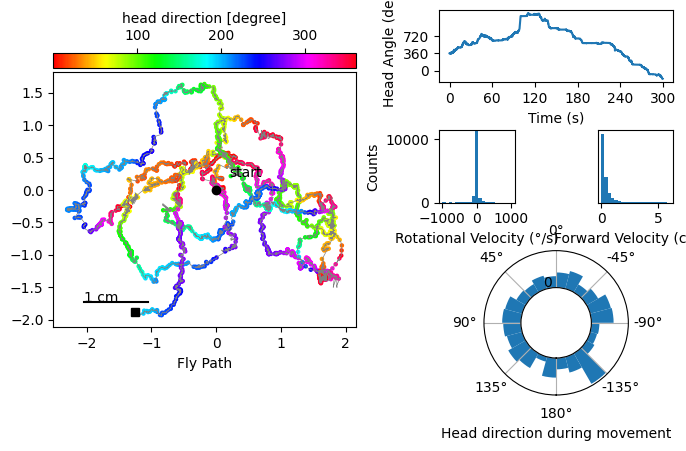

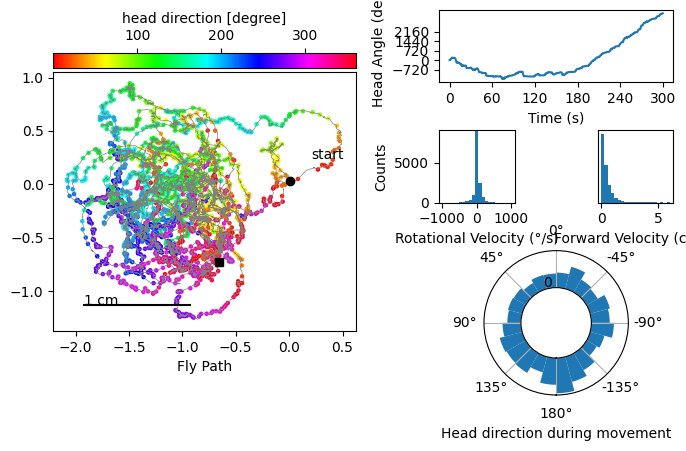

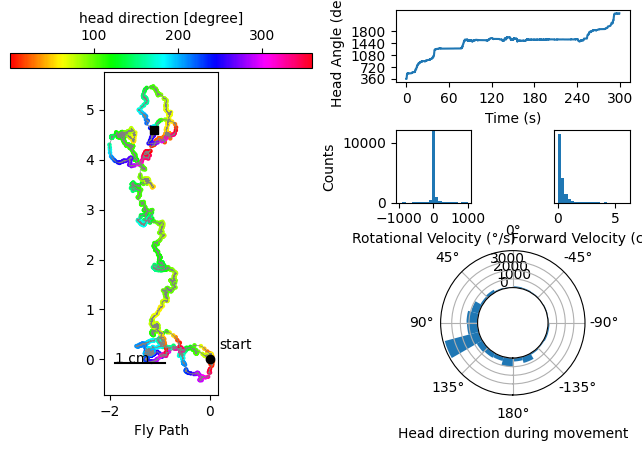

In [ ]:
convfac = 10 # dc2cm

figsize = (8,5)

for index, (trial_type, uvr) in enumerate(uvr_dict.items()):
    fig = plt.figure(figsize=figsize)
    axd = plotting.plot_general_stim(uvr, fig)
    file_name = f"{uvr.metadata['date']}_{uvr.metadata['time']}_{trial_type}"

    # fig.savefig(Path(outfolder,file_name).with_suffix(".png"), dpi=600)
    # fig.savefig(Path(outfolder,file_name).with_suffix(".svg"), dpi=600)

## Create population plot

### Compute statistics

In [6]:
def get_wolb_status(file_name):
    if len(re.findall(r'\+', file_name)) >= 1:
        wolb_status = '+'
    elif len(re.findall(r'-', file_name)) >= 1:
        wolb_status = '-'
    return wolb_status

def get_fly_type(file_name):
    # https://stackoverflow.com/questions/4289331/how-to-extract-numbers-from-a-string-in-python
    try:
        fly_num = re.findall(r'\d+', file_name)[0]
    except:
        print(file_name)
        fly_num = file_name
    wolb_status = get_wolb_status(file_name)
    
    return fly_num + wolb_status

def get_fly_cond(file_name):
    for stim in stimuli_set:
        if stim in file_name:
            return stim
    return None

In [7]:
def get_circ_r(posDf, quantile=0.25):
    # 
    # print(posDf.head())
    radangle_filt = posDf[posDf['vT_filt'] > posDf['vT_filt'].quantile(quantile)]['radangle']
    try:
        circ_r = pingouin.circ_r(radangle_filt)
    except:
        circ_r = None
    return circ_r

def get_skew(posDf):
    return stats.skew(posDf['vR_filt'])

def get_kurtosis(posDf):
    return stats.kurtosis(posDf['vR_filt'])


In [ ]:
print(trial.posDf.head())

   frame      time        dt         x         y     angle        dx  \
0    1.0  0.000000  0.020000  0.000000  0.000000  0.000000  0.000000   
1    2.0  0.020000  0.020000 -0.000036 -0.000083  0.039764 -0.000036   
2    3.0  0.025711  0.005711 -0.000036 -0.000083  0.039764  0.000000   
3    4.0  0.027099  0.001388  0.001432 -0.000016  0.681793  0.001468   
4    5.0  0.028565  0.001466  0.001432 -0.000016  0.681793  0.000000   

         dy  dxattempt  dyattempt        vT        vR   vT_filt   vR_filt  \
0  0.000000   0.000000   0.000000  0.045512  0.039764 -0.500797 -0.005027   
1 -0.000083  -0.000036  -0.000083  0.022756  0.019882  1.147304  0.153758   
2  0.000000   0.000000   0.000000  1.286888  0.321014  1.978564  0.233317   
3  0.000066   0.001468   0.000066  5.295627  0.321014  2.209621  0.228885   
4  0.000000   0.000000   0.000000  0.000000  0.000000  2.388569  0.090941   

         ds         s       dTh  radangle  
0  0.000000  0.000000  0.000000  0.000000  
1  0.000091  0.0

In [ ]:
# pd.DataFrame(df_dicts)

,fly_type,wolb_status,cond,circ_r,skew,kurtosis
0,1+,-,closed_loop,0.260871,-0.993533,12.268056
1,1+,-,dark,0.134032,-0.728310,8.676625
2,1+,-,grating,0.100059,-0.823082,14.649704
3,1-,-,closed_loop,0.640501,0.555726,7.853234
4,1-,-,dark,0.038881,-0.218881,5.641165
...,...,...,...,...,...,...
58,9-,-,dark,0.411612,-0.676894,10.446666
59,9-,-,grating,0.312423,-0.276033,7.044559
60,Back up (-)--,-,closed_loop,0.297391,0.758594,6.186041
61,Back up (-)--,-,dark,0.156214,-0.288306,3.203549


In [11]:
df_dicts = []
for trial_pickle_path in pickle_dir.rglob("*.pickle"):
    with open(trial_pickle_path, 'rb') as file:
        trial = pickle.load(file)
    # Check if uvr object has computed velocities, if not compute them
    if not {'vT', 'vR'}.issubset(trial.posDf.columns):
        trial.posDf = posAnalysis.computeVelocities(trial.posDf)
    # Check if uvr object has derived head angle in rads, if not compute them
    if 'radangle' not in trial.posDf.columns:
        trial.posDf = posAnalysis.position(trial, derive=True)
    # print(uvr.posDf.head())
    fly_type = get_fly_type(trial_pickle_path.parent.name)
    wolb_status = get_wolb_status(trial_pickle_path.parent.name)
    cond = get_fly_cond(trial_pickle_path.name)
    circ_r = get_circ_r(trial.posDf)
    skew = get_skew(trial.posDf)
    kurtosis = get_kurtosis(trial.posDf)
    df_dicts.append({'fly_type': fly_type,
                     'wolb_status': wolb_status,
                     'cond': cond,
                     'circ_r': circ_r,
                     'skew': skew,
                     'kurtosis': kurtosis,})
    # print(trial.posDf)
    # break
population_df = pd.DataFrame(df_dicts)
population_df

Back up (-)-
Back up (-)-
Back up (-)-


,fly_type,wolb_status,cond,circ_r,skew,kurtosis
0,1+,+,closed_loop,0.260871,36.417924,2823.677586
1,1+,+,dark,0.134032,-49.131640,3576.310726
2,1+,+,grating,0.100059,69.364052,5208.420368
3,1-,-,closed_loop,0.640501,-18.801385,1490.253187
4,1-,-,dark,0.038881,-46.145906,2560.803343
...,...,...,...,...,...,...
58,9-,-,dark,0.411612,-0.513152,12.245525
59,9-,-,grating,0.312423,-0.537224,9.843311
60,Back up (-)--,-,closed_loop,0.297391,0.926039,9.137165
61,Back up (-)--,-,dark,0.156214,-0.361086,4.672161


### Plot data

In [12]:
population_df.to_csv(Path(r"Z:\GULP\results\wolbachia", "raw_data.csv"))

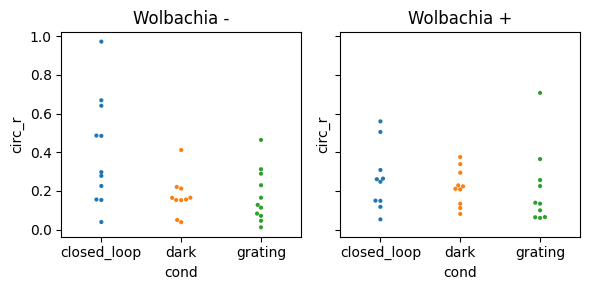

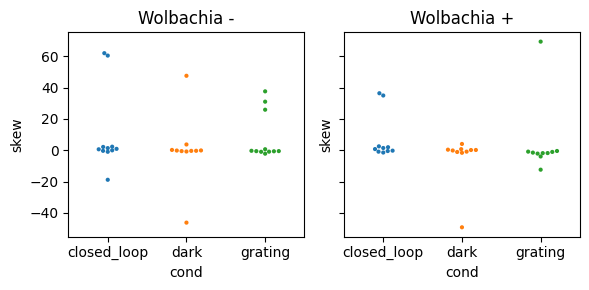

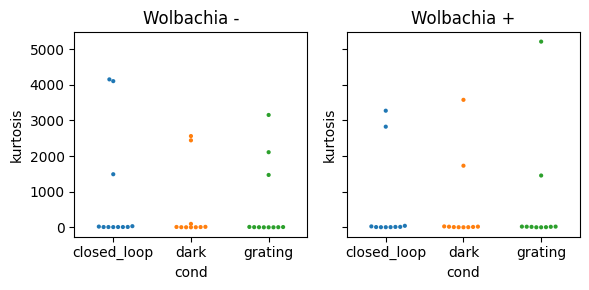

In [14]:
for stat in ['circ_r', 'skew', 'kurtosis']:
    fig, axs = plt.subplots(1,2, layout='tight', figsize=(6,3), sharey=True)
    wolb_neg_df = population_df[population_df['wolb_status'] == '-']
    wolb_pos_df = population_df[population_df['wolb_status'] == '+']
    sns.swarmplot(data=wolb_neg_df,
                  x='cond',
                  y=stat,
                  size=3,
                  ax=axs[0])
    sns.swarmplot(data=wolb_pos_df,
                  x='cond',
                  y=stat,
                  size=3,
                  ax=axs[1])
    axs[0].set_title("Wolbachia -")
    axs[1].set_title("Wolbachia +")
    fig.savefig(Path(r"Z:\GULP\results\wolbachia", stat+".svg"))


## Plot all pickles

In [4]:
outfolder = Path("Z:\FlyVR\results\wolb_plots")

In [16]:
for trial_pickle_path in pickle_dir.rglob("*.pickle"):
    with open(trial_pickle_path, 'rb') as file:
        trial = pickle.load(file)
    # Check if uvr object has computed velocities, if not compute them
    if not {'vT', 'vR'}.issubset(trial.posDf.columns):
        trial.posDf = posAnalysis.computeVelocities(trial.posDf)
    # Check if uvr object has derived head angle in rads, if not compute them
    if 'radangle' not in trial.posDf.columns:
        trial.posDf = posAnalysis.position(trial, derive=True)
    # print(uvr.posDf.head())
    fly_type = get_fly_type(trial_pickle_path.parent.name)
    wolb_status = get_wolb_status(trial_pickle_path.parent.name)
    cond = get_fly_cond(trial_pickle_path.name)

    # Create plot
    if cond == 'dark':
        fig, axd = plotting.plot_dark_stim(trial)

    if cond == 'grating':
        fig, axd = plotting.plot_grating_stim(trial)

    if cond == 'closed_loop':
        fig, axd = plotting.plot_closed_loop_stim(trial)
    
    file_name = f"{trial.metadata['date']}_{trial.metadata['time']}_{cond}"
    outpath = Path(outfolder, fly_type, file_name)
    # Make directory if it doesn't exits
    outpath.parent.mkdir(parents=True, exist_ok=True)

    # Save figure
    fig.savefig(outpath.with_suffix(".png"), dpi=600)
    fig.savefig(outpath.with_suffix(".svg"), dpi=600)
    plt.close()


Back up (-)-
Back up (-)-
Back up (-)-


In [13]:
axd

(<Figure size 640x480 with 3 Axes>,
 {'path': <Axes: xlabel='Fly Path'>,
  'hist_angle': <PolarAxes: xlabel='Head direction during movement'>})